# 🏭 Research-paper replication: industry momentum

## 🧭 tl;dr

Moskowitz and Grinblatt’s **Do Industries Explain Momentum?** argues that momentum is strong at the industry level. This notebook uses sector ETFs as a liquid proxy: rank sectors by prior intermediate-term returns, buy the strongest sectors, and short the weakest.

> Educational research only. Not financial advice. Sector ETFs are not the original stock-level industry portfolios.

<div style="border-left: 5px solid #16A34A; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #F0FDF4; border-radius: 8px;"><strong>🧑‍🏫 Reader guide</strong><br>Industry momentum is cross-sectional momentum at a different level. The notebook makes that hierarchy visible and tests whether the result survives costs and an untouched period.</div>


## 📚 Paper and research question

[Moskowitz and Grinblatt, *Do Industries Explain Momentum?*](https://doi.org/10.1111/0022-1082.00146) documents momentum in industry components and finds industry momentum strategies remain profitable after several controls.

**Research question:** does a simple long-short sector momentum portfolio behave differently from broad ETF buy and hold, and does it remain useful out of sample?


In [1]:

from pathlib import Path
import sys
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    if (ROOT.parent / "src").exists():
        ROOT = ROOT.parent
    elif "__file__" in globals():
        ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.backtest import split_time_series
from src.data import load_price_panel, make_demo_ohlcv
from src.portfolio import run_portfolio_backtest
from src.research import metrics_for_period

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


In [2]:

def load_sector_panel():
    tickers=["XLY","XLP","XLE","XLF","XLV","XLI","XLB","XLK","XLU","IYR"]
    try:
        panel=load_price_panel(tickers,"2004-01-01","2026-01-01")
        source="Yahoo Finance adjusted daily sector ETF closes"
    except Exception as exc:
        demo=make_demo_ohlcv(periods=5_500,seed=1001,start="2004-01-01")["close"]
        panel=pd.DataFrame({ticker:demo*(1.0+0.015*i) for i,ticker in enumerate(tickers)},index=demo.index)
        source=f"deterministic demo sector panel fallback ({type(exc).__name__})"
    return panel.dropna(),source


close,data_source=load_sector_panel()
print(f"Data source: {data_source}")
print(f"Observations: {len(close):,} | {close.index.min().date()} to {close.index.max().date()}")
display(close.head())


Data source: Yahoo Finance adjusted daily sector ETF closes
Observations: 5,535 | 2004-01-02 to 2025-12-31


,IYR,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,,
2004-01-02,21.661669,8.164501,7.365887,14.541997,17.559765,7.685285,12.113166,5.375395,20.761139,11.897471
2004-01-05,21.670420,8.330496,7.507641,14.661064,17.730513,7.872914,12.191970,5.384638,20.857317,12.000370
2004-01-06,21.709820,8.256726,7.499619,14.655887,17.704241,7.944211,12.220117,5.373085,20.919147,12.046094
2004-01-07,21.613523,8.213683,7.422054,14.666244,17.730513,7.981740,12.169456,5.400805,21.049679,12.099450
2004-01-08,21.657290,8.305904,7.443451,14.718008,17.842150,8.139349,12.152575,5.398496,20.960375,12.061339


## 📜 Strategy rules

At each month start:

1. Compute each sector’s prior 6-month return using a one-month skip.
2. Rank the sectors cross-sectionally.
3. Go long the top three sectors with total long exposure of 0.50.
4. Short the bottom three sectors with total short exposure of −0.50.
5. Hold until the next monthly rebalance.

This is a long-short factor proxy. It does not include individual-stock industry classifications, value weighting, country controls, or the paper’s full factor regressions.


In [3]:

def industry_momentum_weights(close,lookback=126,skip_recent=21,top_n=3):
    score=close.shift(skip_recent).pct_change(lookback)
    month=close.index.to_period("M")
    month_start=pd.Series(month,index=close.index).ne(pd.Series(month,index=close.index).shift(1))
    candidates=pd.DataFrame(0.0,index=close.index,columns=close.columns)
    for timestamp in close.index[month_start.to_numpy()]:
        valid=score.loc[timestamp].dropna()
        if len(valid)>=2*top_n:
            winners=valid.nlargest(top_n).index
            losers=valid.nsmallest(top_n).index
            candidates.loc[timestamp,winners]=0.5/top_n
            candidates.loc[timestamp,losers]=-0.5/top_n
    weights=pd.DataFrame(np.nan,index=close.index,columns=close.columns)
    weights.loc[month_start]=candidates.loc[month_start]
    return weights.ffill().fillna(0.0)


weights=industry_momentum_weights(close)
industry_result=run_portfolio_backtest(close,weights,transaction_cost_bps=10.0,benchmark_returns=close["XLY"].pct_change().fillna(0.0))
sector_equal=run_portfolio_backtest(close,pd.DataFrame(1.0/len(close.columns),index=close.index,columns=close.columns),transaction_cost_bps=10.0,benchmark_returns=close["XLY"].pct_change().fillna(0.0))
xly_hold=run_portfolio_backtest(close,pd.DataFrame({"XLY":1.0,**{c:0.0 for c in close.columns if c!="XLY"}},index=close.index),transaction_cost_bps=10.0,benchmark_returns=close["XLY"].pct_change().fillna(0.0))
splits=split_time_series(close)
periods={name:frame.index for name,frame in splits.items()}


## 📈 Results: industry momentum versus controls

The benchmark is XLY because it is the first sector ETF in the panel; equal-weight sector buy and hold is included as a broader diversification control. The factor portfolio is dollar-neutral in the simple backtester, with gross exposure of 1.0 before any implementation costs.


In [4]:

rows=[]
for name,backtest in [("Industry momentum",industry_result),("Equal-weight sectors",sector_equal),("XLY buy & hold",xly_hold)]:
    for period_name,period_index in periods.items():
        metrics=metrics_for_period(backtest,period_index)
        rows.append({"strategy":name,"period":period_name,**metrics})
summary=pd.DataFrame(rows).set_index(["strategy","period"])
display(summary[["annualized_return","annualized_volatility","sharpe_ratio","sortino_ratio","max_drawdown","calmar_ratio","win_rate","annualized_turnover","number_of_trades","total_return_after_costs"]].style.format({"annualized_return":"{:.2%}","annualized_volatility":"{:.2%}","sharpe_ratio":"{:.2f}","sortino_ratio":"{:.2f}","max_drawdown":"{:.2%}","calmar_ratio":"{:.2f}","win_rate":"{:.2%}","annualized_turnover":"{:.2f}","number_of_trades":"{:.0f}","total_return_after_costs":"{:.2%}"}))


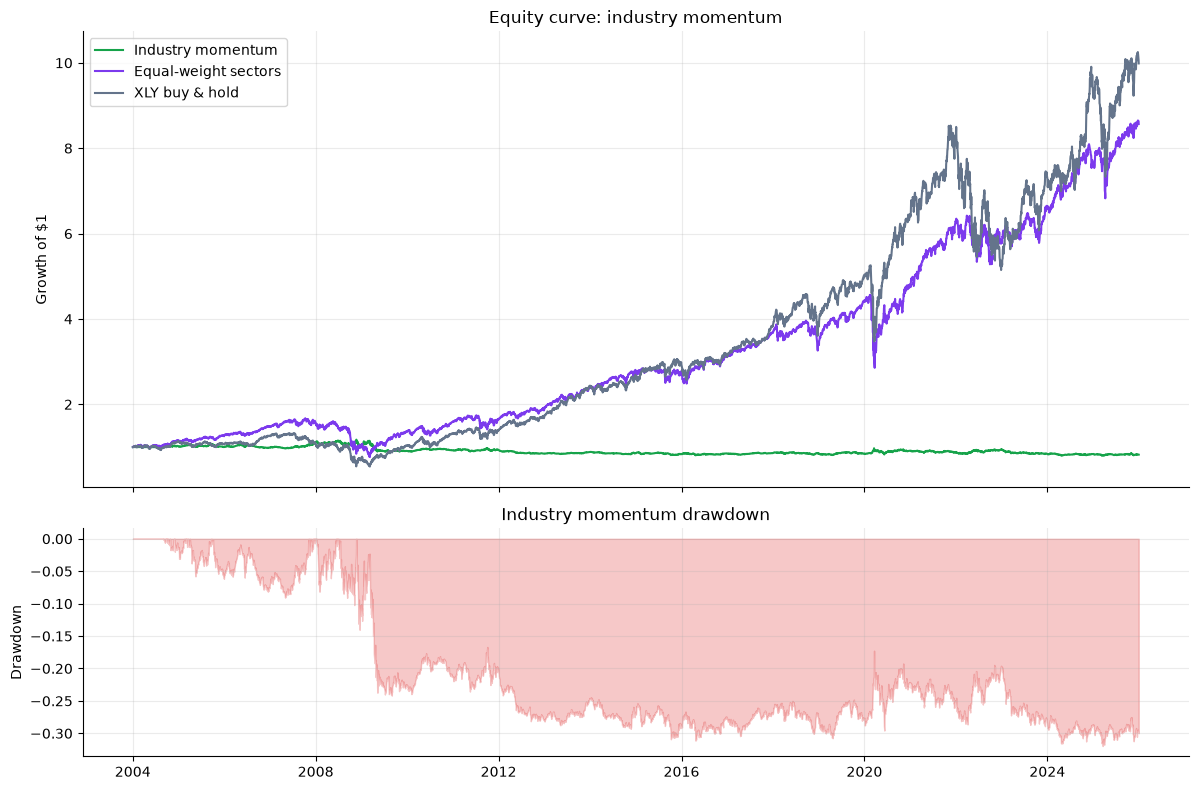

In [5]:

fig,axes=plt.subplots(2,1,figsize=(12,8),sharex=True,gridspec_kw={"height_ratios":[2,1]})
for backtest,label,color in [(industry_result,"Industry momentum","#16A34A"),(sector_equal,"Equal-weight sectors","#7C3AED"),(xly_hold,"XLY buy & hold","#64748B")]:
    axes[0].plot(backtest.frame.index,backtest.frame.equity/backtest.frame.equity.iloc[0],label=label,color=color)
axes[0].set_title("Equity curve: industry momentum")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[1].fill_between(industry_result.frame.index,industry_result.frame.drawdown,0,color="#DC2626",alpha=0.25)
axes[1].set_title("Industry momentum drawdown")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()


## 🧪 Robustness checks

We vary the formation horizon and the number of long/short sectors. The original proxy uses six months and three sectors; the untouched test remains tied to that rule.


In [6]:

grid_rows=[]
for lookback,top_n in itertools.product([63,126,252],[2,3,4]):
    candidate_weights=industry_momentum_weights(close,lookback,21,top_n)
    candidate=run_portfolio_backtest(close,candidate_weights,transaction_cost_bps=10.0,benchmark_returns=close["XLY"].pct_change().fillna(0.0))
    validation=metrics_for_period(candidate,periods["validation"])
    test=metrics_for_period(candidate,periods["test"])
    grid_rows.append({"lookback":lookback,"top_n":top_n,"validation_sharpe":validation["sharpe_ratio"],"validation_return":validation["annualized_return"],"test_sharpe":test["sharpe_ratio"],"test_return":test["annualized_return"],"test_drawdown":test["max_drawdown"]})
sensitivity=pd.DataFrame(grid_rows).sort_values("validation_sharpe",ascending=False)
display(sensitivity.style.format({"validation_sharpe":"{:.2f}","validation_return":"{:.2%}","test_sharpe":"{:.2f}","test_return":"{:.2%}","test_drawdown":"{:.2%}"}))


,lookback,top_n,validation_sharpe,validation_return,test_sharpe,test_return,test_drawdown
3,126,2,0.37,3.25%,-0.21,-2.34%,-20.59%
1,63,3,0.36,2.60%,-0.78,-6.13%,-29.94%
0,63,2,0.26,2.07%,-0.75,-7.38%,-33.46%
2,63,4,0.21,1.23%,-0.83,-5.44%,-27.07%
4,126,3,0.17,1.08%,-0.17,-1.54%,-15.52%
5,126,4,0.14,0.70%,-0.31,-2.08%,-14.36%
6,252,2,0.12,0.68%,-0.14,-1.66%,-20.33%
8,252,4,-0.06,-0.68%,0.03,0.00%,-12.89%
7,252,3,-0.19,-1.99%,0.11,0.50%,-15.47%


In [7]:

cost_rows=[]
for cost_bps in [0,10,25,50]:
    cost_result=run_portfolio_backtest(close,weights,transaction_cost_bps=cost_bps,benchmark_returns=close["XLY"].pct_change().fillna(0.0))
    metrics=metrics_for_period(cost_result,periods["test"])
    cost_rows.append({"transaction_cost_bps":cost_bps,"test_return":metrics["annualized_return"],"test_sharpe":metrics["sharpe_ratio"],"test_drawdown":metrics["max_drawdown"],"test_turnover":metrics["annualized_turnover"]})
display(pd.DataFrame(cost_rows).style.format({"test_return":"{:.2%}","test_sharpe":"{:.2f}","test_drawdown":"{:.2%}","test_turnover":"{:.2f}"}))


,transaction_cost_bps,test_return,test_sharpe,test_drawdown,test_turnover
0,0,-0.76%,-0.07,-14.23%,7.89
1,10,-1.54%,-0.17,-15.52%,7.89
2,25,-2.70%,-0.33,-17.53%,7.89
3,50,-4.61%,-0.59,-22.53%,7.89


## ⚖️ What went well / what went wrong

### ✅ What went well

- The strategy tests momentum at the industry level rather than simply repeating stock or broad-asset momentum.
- A dollar-neutral design makes market direction less central to the hypothesis.
- The equal-weight sector control helps separate timing from simple diversification.

### ⚠️ What went wrong or remains uncertain

- Sector ETFs are imperfect industry portfolios and have different inception dates, fees, liquidity, and concentration.
- The small universe makes rankings coarse and can amplify one sector’s idiosyncratic move.
- Shorting ETFs introduces borrow, financing, and dividend considerations not modeled here.
- The paper’s conclusions come from a much richer stock-level dataset and statistical controls.

**Bottom line:** industry momentum is a distinct and useful research dimension, but this ETF proxy is evidence about a simplified sector-rotation rule—not a direct estimate of the paper’s factor premium.
